<a href="https://colab.research.google.com/github/dairo123e/transformacion-texto-embeddings/blob/main/Transformacion_texto_embeddings_Dairo_Contreras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
"""Laboratorio: transformacion de texto en embeddings.
Autor: Dairo Enrique Contreras Quintana
Procesamiento de Lenguaje Natural
"""

from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

SEED = 42
OUTPUT_DIR = Path("resultados_embeddings")
OUTPUT_DIR.mkdir(exist_ok=True)

TEXTOS = [
    "TensorFlow permite construir y entrenar modelos de aprendizaje profundo.",
    "Las redes neuronales aprenden patrones a partir de datos de entrenamiento.",
    "El aprendizaje automatico permite que los sistemas mejoren con la experiencia.",
    "Keras simplifica la construccion de redes neuronales sobre TensorFlow.",
    "Los embeddings representan palabras y documentos mediante vectores densos.",
    "La similitud coseno compara la orientacion de dos representaciones vectoriales.",
    "La tokenizacion divide un texto en palabras, subpalabras u otras unidades.",
    "TF-IDF asigna mayor peso a los terminos relevantes de cada documento.",
    "Python se utiliza ampliamente en ciencia de datos e inteligencia artificial.",
    "El procesamiento de lenguaje natural permite analizar informacion escrita.",
    "Los modelos de lenguaje procesan secuencias para comprender contexto.",
    "La clasificacion de textos asigna categorias a documentos automaticamente.",
    "Un cultivo necesita agua, nutrientes y condiciones adecuadas de temperatura.",
    "La agricultura de precision utiliza sensores para supervisar los cultivos.",
    "El ganado requiere alimentacion equilibrada y seguimiento sanitario.",
    "Los sistemas ganaderos registran produccion, salud y reproduccion animal.",
    "El futbol universitario fortalece el trabajo en equipo y la resistencia.",
    "Los jugadores entrenan pases, control del balon y estrategias deportivas."
]

ETIQUETAS = [
    "IA", "IA", "IA", "IA", "PLN", "PLN", "PLN", "PLN", "IA",
    "PLN", "PLN", "PLN", "AGRO", "AGRO", "AGRO", "AGRO", "DEPORTE", "DEPORTE"
]


def fijar_semillas(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def guardar_heatmap(matriz, etiquetas, titulo, archivo):
    """ Mapa de calor."""
    fig, ax = plt.subplots(figsize=(12, 10))
    imagen = ax.imshow(matriz, cmap="viridis", vmin=np.min(matriz), vmax=1)
    ax.set_title(titulo)
    ax.set_xticks(range(len(etiquetas)))
    ax.set_yticks(range(len(etiquetas)))
    ax.set_xticklabels(etiquetas, rotation=90, fontsize=7)
    ax.set_yticklabels(etiquetas, fontsize=7)
    fig.colorbar(imagen, ax=ax, label="Similitud coseno")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / archivo, dpi=220)
    plt.close(fig)


def encontrar_extremos(matriz):
    """Devuelve el par mas similar y el menos similar, sin considerar la diagonal."""
    m = matriz.copy()
    np.fill_diagonal(m, np.nan)
    max_pos = np.unravel_index(np.nanargmax(m), m.shape)
    min_pos = np.unravel_index(np.nanargmin(m), m.shape)
    return max_pos, float(m[max_pos]), min_pos, float(m[min_pos])


def analizar_tfidf(textos):
    vectorizador = TfidfVectorizer(lowercase=True, ngram_range=(1, 2))
    matriz = vectorizador.fit_transform(textos)
    similitud = cosine_similarity(matriz)
    pd.DataFrame(matriz.toarray(), columns=vectorizador.get_feature_names_out()).to_csv(
        OUTPUT_DIR / "vectores_tfidf.csv", index=False
    )
    guardar_heatmap(similitud, [f"T{i+1}" for i in range(len(textos))],
                    "Similitud entre textos con TF-IDF", "heatmap_tfidf.png")
    return matriz, similitud, vectorizador


def crear_vectorizador(textos, longitud=16):
    capa = tf.keras.layers.TextVectorization(
        max_tokens=2000,
        standardize="lower_and_strip_punctuation",
        split="whitespace",
        output_mode="int",
        output_sequence_length=longitud,
        name="vectorizacion"
    )
    capa.adapt(tf.data.Dataset.from_tensor_slices(textos).batch(8))
    return capa


def construir_modelo(vectorizador, numero_clases, dimension=32):
    entradas = tf.keras.Input(shape=(1,), dtype=tf.string, name="texto")
    secuencias = vectorizador(entradas)
    capa_embedding = tf.keras.layers.Embedding(
        input_dim=len(vectorizador.get_vocabulary()),
        output_dim=dimension,
        mask_zero=True,
        name="embedding"
    )
    embeddings = capa_embedding(secuencias)
    representacion = tf.keras.layers.GlobalAveragePooling1D(name="mean_pooling")(embeddings)
    x = tf.keras.layers.Dense(32, activation="relu", name="capa_densa")(representacion)
    x = tf.keras.layers.Dropout(0.20)(x)
    salidas = tf.keras.layers.Dense(numero_clases, activation="softmax", name="clasificacion")(x)
    modelo = tf.keras.Model(entradas, salidas)
    extractor = tf.keras.Model(entradas, representacion)
    modelo.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo, extractor


def graficar_entrenamiento(historia):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(historia.history["loss"])
    axes[0].set_title("Perdida durante el entrenamiento")
    axes[0].set_xlabel("Epoca")
    axes[0].set_ylabel("Perdida")
    axes[1].plot(historia.history["accuracy"])
    axes[1].set_title("Exactitud durante el entrenamiento")
    axes[1].set_xlabel("Epoca")
    axes[1].set_ylabel("Exactitud")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "entrenamiento.png", dpi=220)
    plt.close(fig)


def graficar_pca(vectores, categorias):
    coords = PCA(n_components=2, random_state=SEED).fit_transform(vectores)
    fig, ax = plt.subplots(figsize=(9, 6))
    for categoria in sorted(set(categorias)):
        indices = [i for i, valor in enumerate(categorias) if valor == categoria]
        ax.scatter(coords[indices, 0], coords[indices, 1], label=categoria, s=70)
    for i, (x, y) in enumerate(coords):
        ax.annotate(f"T{i+1}", (x, y), fontsize=8, xytext=(3, 3), textcoords="offset points")
    ax.set_title("Proyeccion PCA de los embeddings de texto")
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "pca_embeddings.png", dpi=220)
    plt.close(fig)


def main():
    fijar_semillas()
    clases = sorted(set(ETIQUETAS))
    clase_a_id = {clase: i for i, clase in enumerate(clases)}
    y = np.array([clase_a_id[c] for c in ETIQUETAS])
    x = np.array(TEXTOS, dtype=object)

    # Linea base interpretable: TF-IDF
    _, similitud_tfidf, vectorizador_tfidf = analizar_tfidf(TEXTOS)

    # Embeddings entrenables con TensorFlow
    vectorizador = crear_vectorizador(TEXTOS)
    modelo, extractor = construir_modelo(vectorizador, len(clases), dimension=32)
    callbacks = [tf.keras.callbacks.EarlyStopping(monitor="loss", patience=20, restore_best_weights=True)]
    historia = modelo.fit(x, y, epochs=250, batch_size=4, verbose=0, callbacks=callbacks)
    graficar_entrenamiento(historia)

    vectores = extractor.predict(x, verbose=0)
    similitud_emb = cosine_similarity(vectores)
    pd.DataFrame(vectores, index=[f"T{i+1}" for i in range(len(TEXTOS))]).to_csv(
        OUTPUT_DIR / "embeddings_tensorflow.csv"
    )
    guardar_heatmap(similitud_emb, [f"T{i+1}" for i in range(len(TEXTOS))],
                    "Similitud entre embeddings entrenados", "heatmap_embeddings.png")
    graficar_pca(vectores, ETIQUETAS)

    max_tfidf, valor_max_tfidf, min_tfidf, valor_min_tfidf = encontrar_extremos(similitud_tfidf)
    max_emb, valor_max_emb, min_emb, valor_min_emb = encontrar_extremos(similitud_emb)

    resumen = {
        "numero_textos": len(TEXTOS),
        "tamano_vocabulario_tensorflow": len(vectorizador.get_vocabulary()),
        "dimension_embedding": int(vectores.shape[1]),
        "epocas_ejecutadas": len(historia.history["loss"]),
        "exactitud_final": float(historia.history["accuracy"][-1]),
        "tfidf_par_mas_similar": [int(max_tfidf[0] + 1), int(max_tfidf[1] + 1)],
        "tfidf_similitud_maxima": valor_max_tfidf,
        "tfidf_par_menos_similar": [int(min_tfidf[0] + 1), int(min_tfidf[1] + 1)],
        "tfidf_similitud_minima": valor_min_tfidf,
        "embedding_par_mas_similar": [int(max_emb[0] + 1), int(max_emb[1] + 1)],
        "embedding_similitud_maxima": valor_max_emb,
        "embedding_par_menos_similar": [int(min_emb[0] + 1), int(min_emb[1] + 1)],
        "embedding_similitud_minima": valor_min_emb,
        "clases": clases,
        "vocabulario_tfidf": int(len(vectorizador_tfidf.get_feature_names_out()))
    }
    with open(OUTPUT_DIR / "resumen_resultados.json", "w", encoding="utf-8") as archivo:
        json.dump(resumen, archivo, ensure_ascii=False, indent=2)

    modelo.save(OUTPUT_DIR / "modelo_embeddings.keras")
    print(json.dumps(resumen, ensure_ascii=False, indent=2))
    print(f"\nArchivos guardados en: {OUTPUT_DIR.resolve()}")


if __name__ == "__main__":
    main()


{
  "numero_textos": 18,
  "tamano_vocabulario_tensorflow": 125,
  "dimension_embedding": 32,
  "epocas_ejecutadas": 137,
  "exactitud_final": 1.0,
  "tfidf_par_mas_similar": [
    2,
    4
  ],
  "tfidf_similitud_maxima": 0.173363564685205,
  "tfidf_par_menos_similar": [
    1,
    5
  ],
  "tfidf_similitud_minima": 0.0,
  "embedding_par_mas_similar": [
    2,
    4
  ],
  "embedding_similitud_maxima": 0.9948567152023315,
  "embedding_par_menos_similar": [
    4,
    15
  ],
  "embedding_similitud_minima": -0.2816576361656189,
  "clases": [
    "AGRO",
    "DEPORTE",
    "IA",
    "PLN"
  ],
  "vocabulario_tfidf": 263
}

Archivos guardados en: /content/resultados_embeddings


VISUALIZACIÓN DE LOS RESULTADOS DEL LABORATORIO

Figura 1. Mapa de calor de similitud con TF-IDF


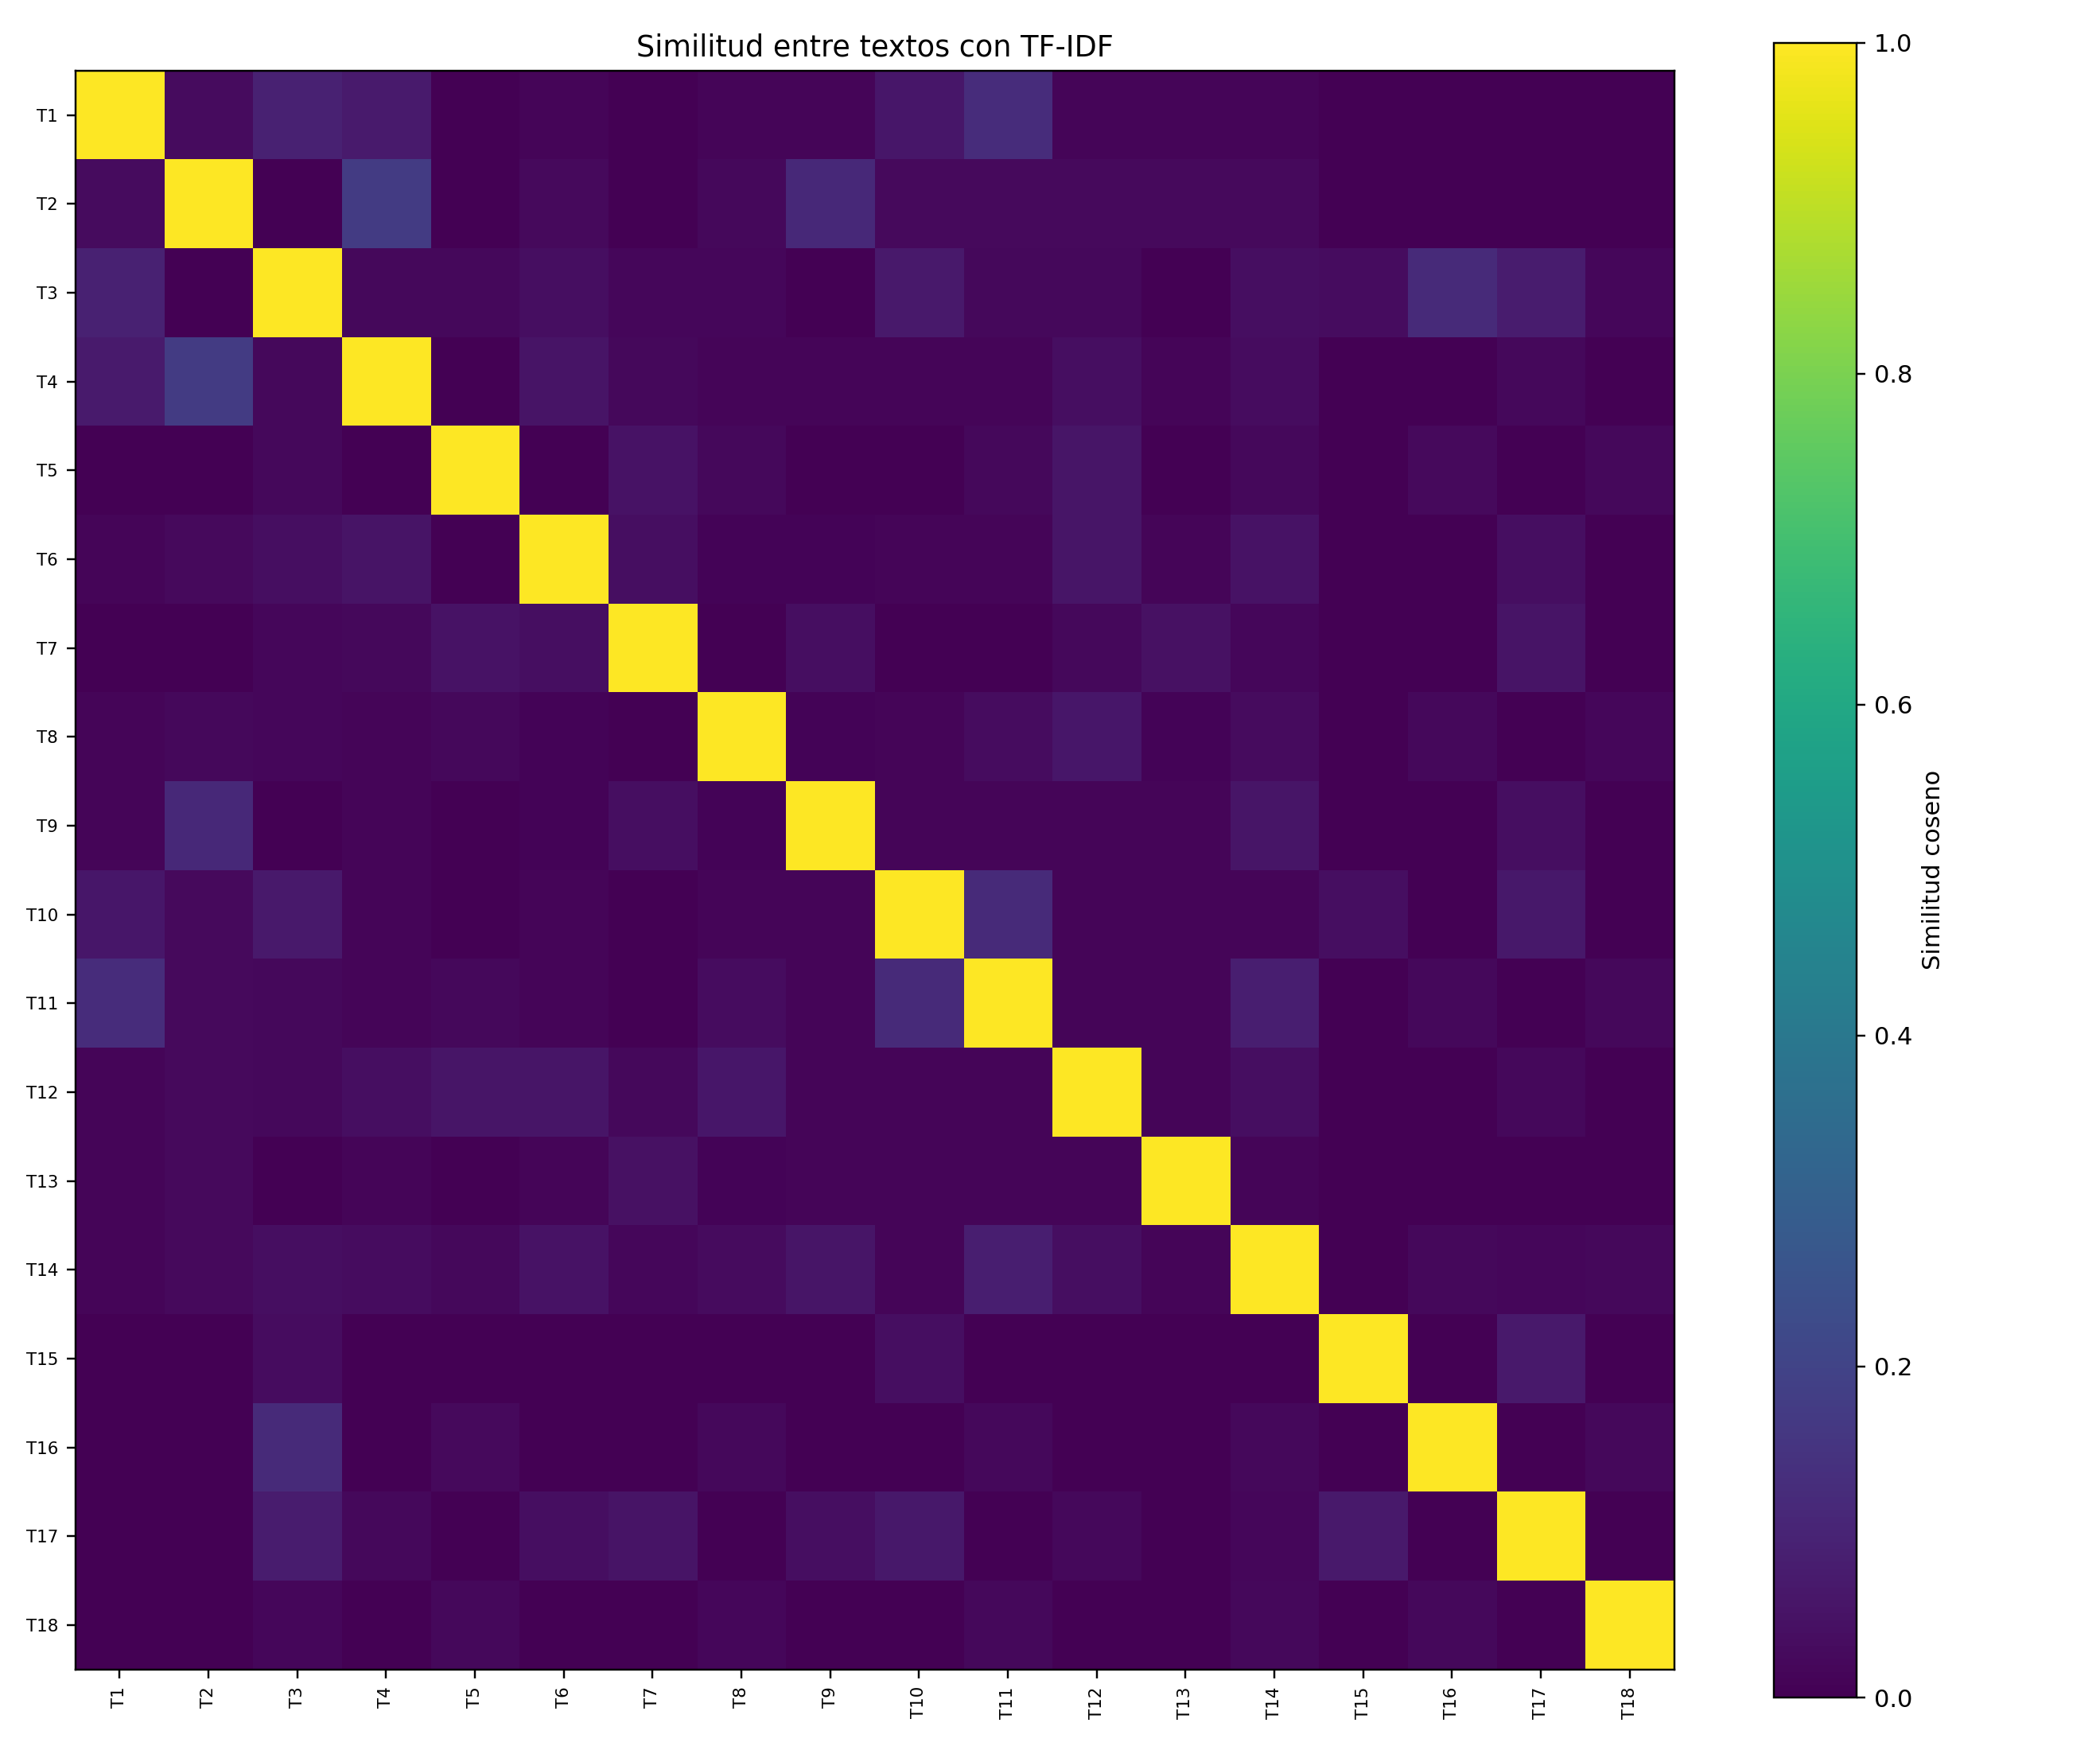


Figura 2. Curvas de pérdida y exactitud del entrenamiento


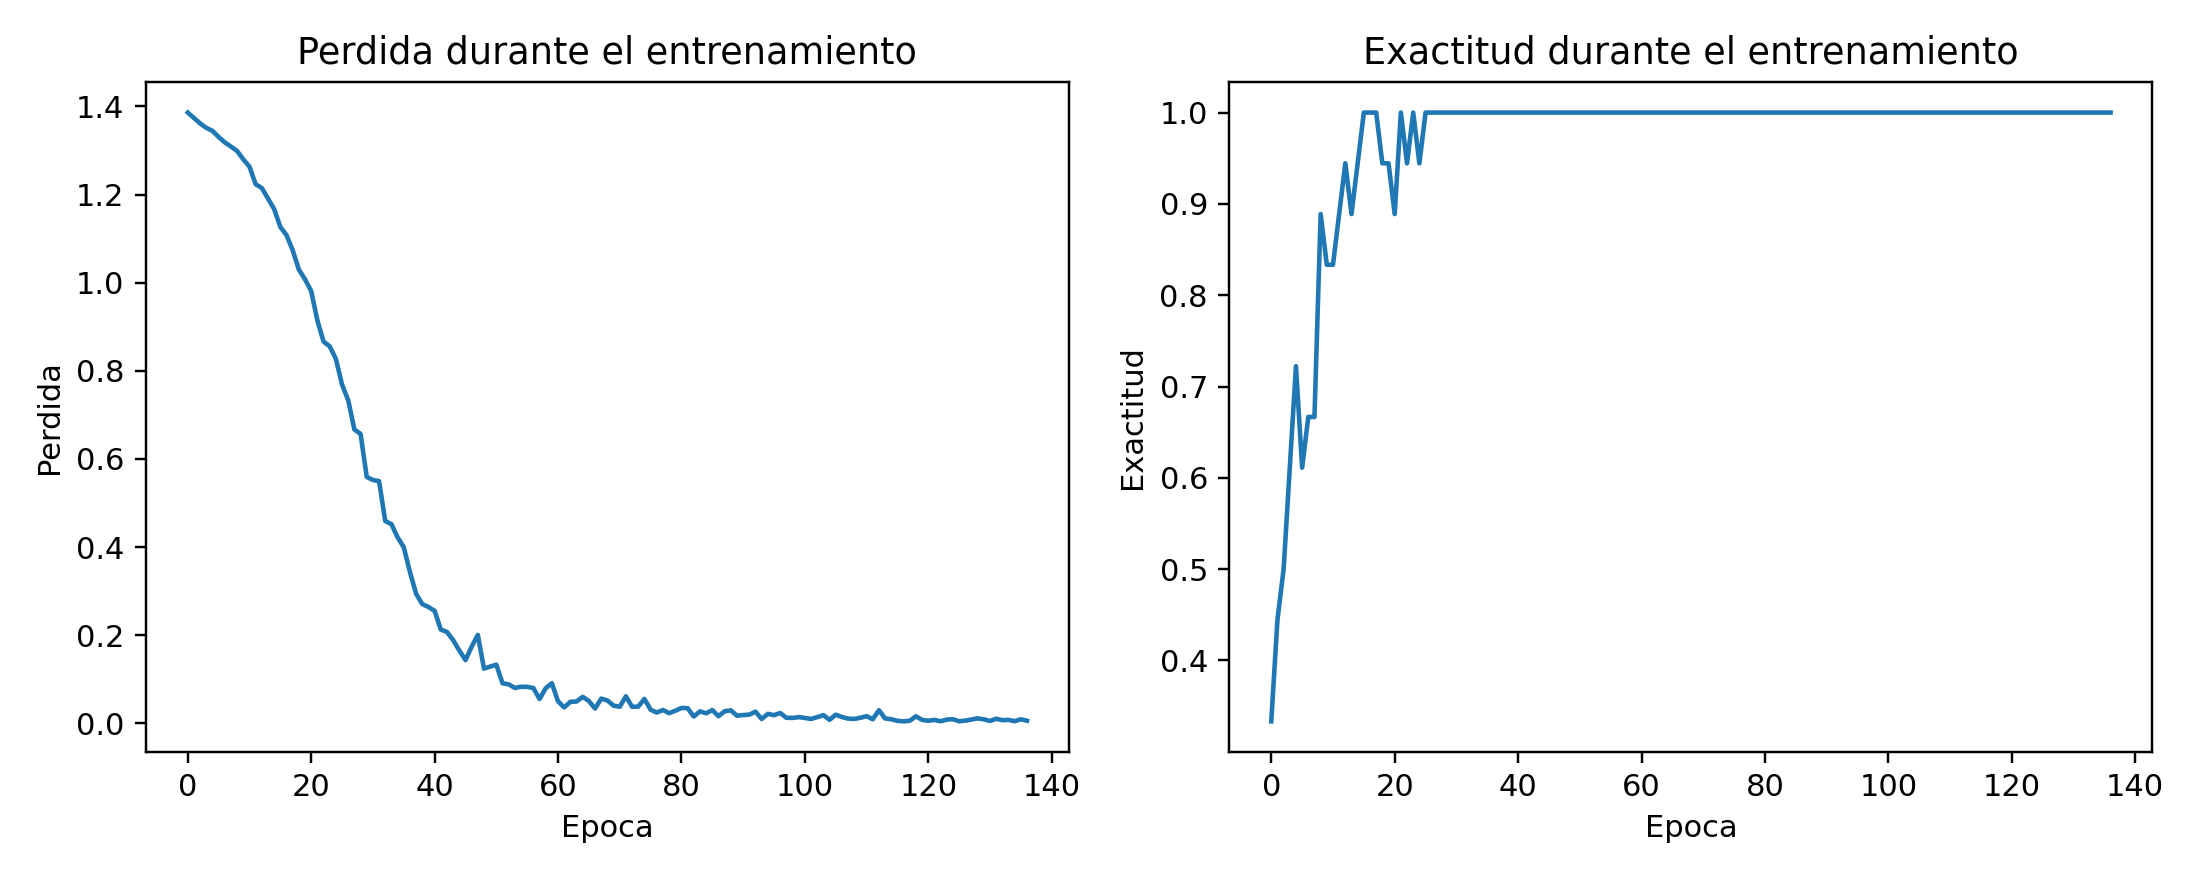


Figura 3. Mapa de calor de similitud entre embeddings


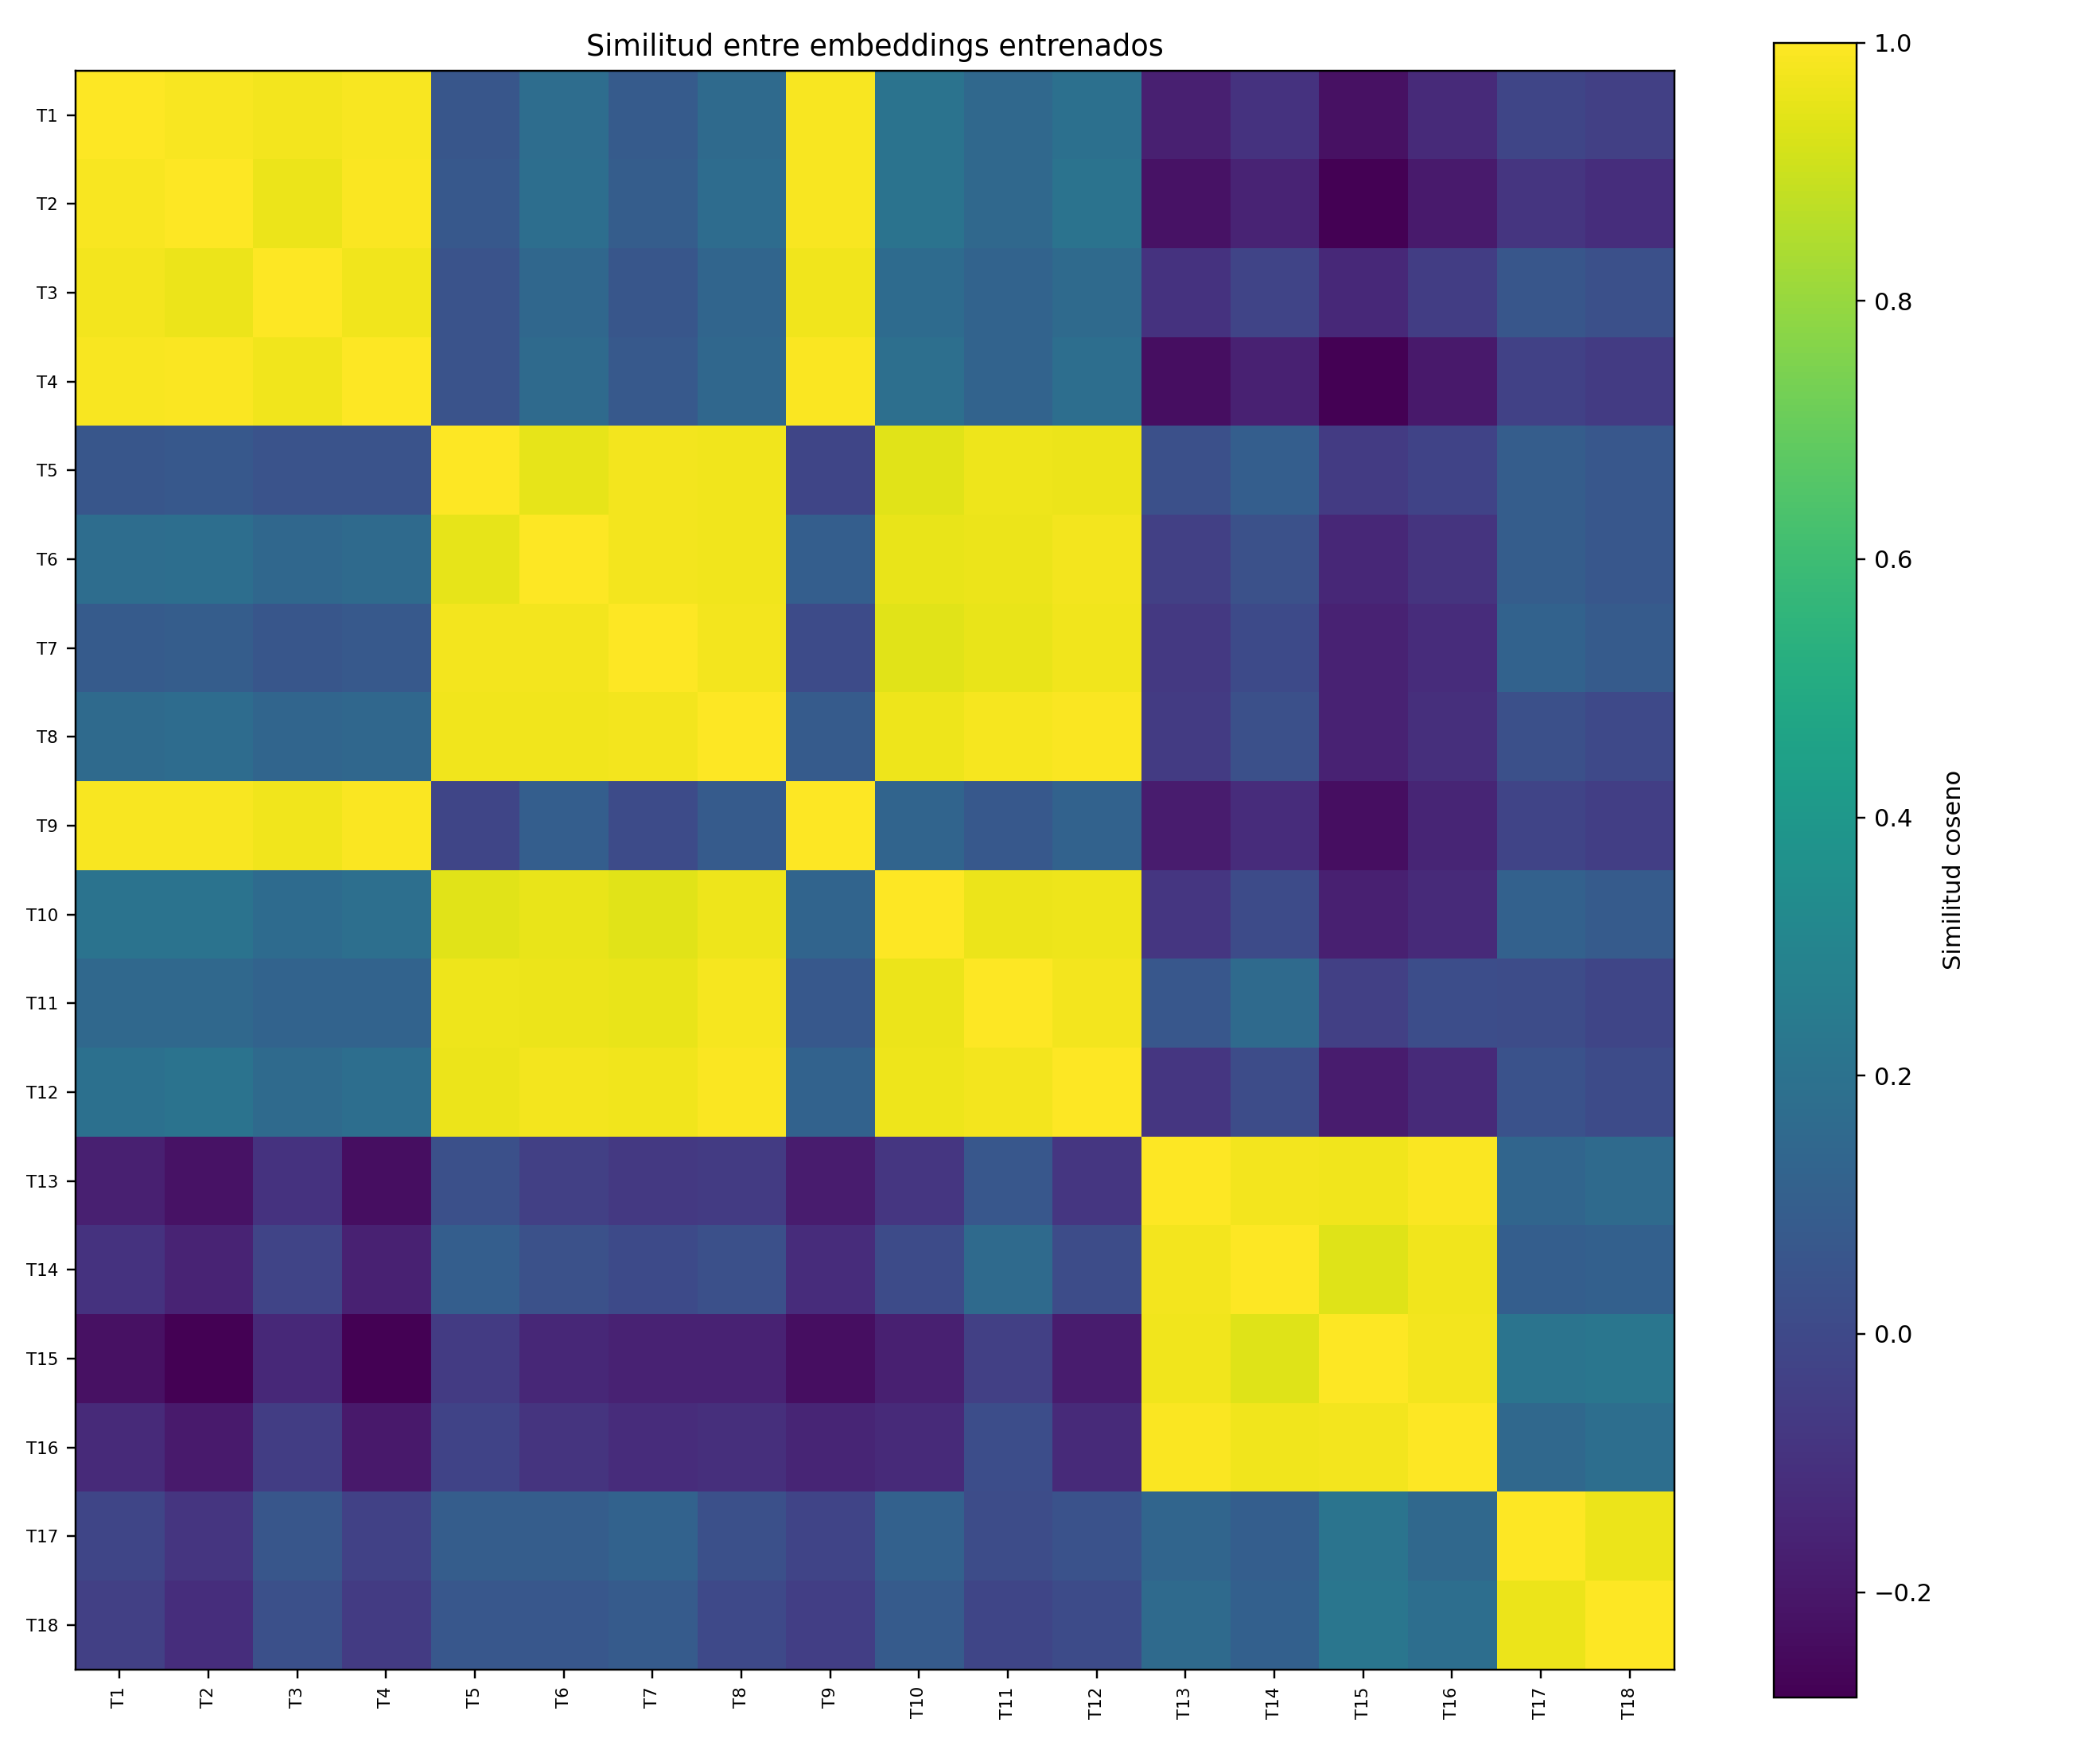


Figura 4. Proyección PCA de los embeddings


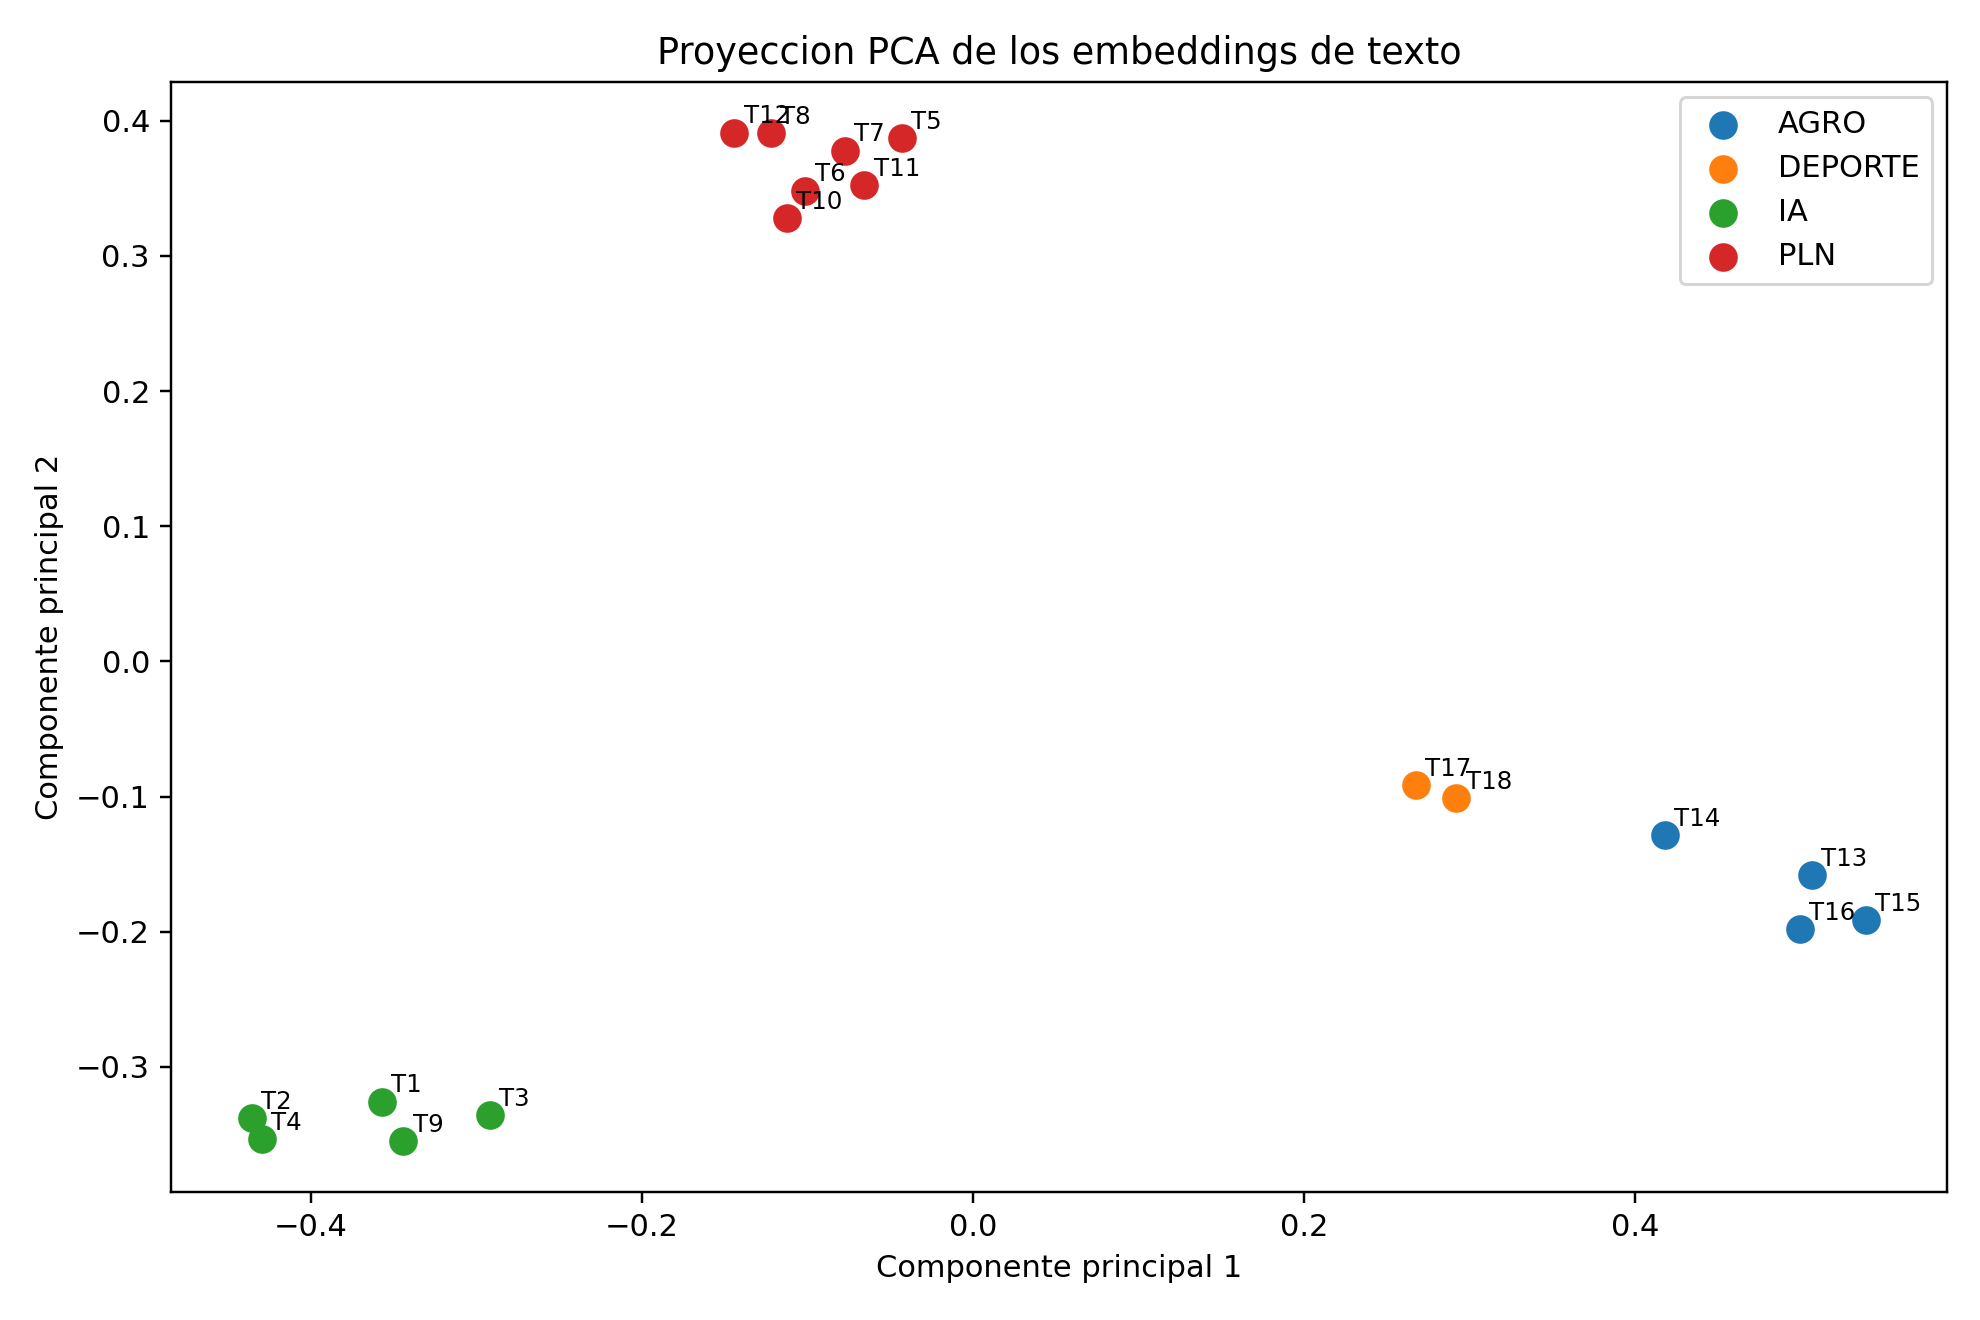

In [3]:
from IPython.display import display, Image
from pathlib import Path

carpeta_resultados = Path("/content/resultados_embeddings")

print("VISUALIZACIÓN DE LOS RESULTADOS DEL LABORATORIO")
print("=" * 60)

print("\nFigura 1. Mapa de calor de similitud con TF-IDF")
display(Image(filename=str(carpeta_resultados / "heatmap_tfidf.png")))

print("\nFigura 2. Curvas de pérdida y exactitud del entrenamiento")
display(Image(filename=str(carpeta_resultados / "entrenamiento.png")))

print("\nFigura 3. Mapa de calor de similitud entre embeddings")
display(Image(filename=str(carpeta_resultados / "heatmap_embeddings.png")))

print("\nFigura 4. Proyección PCA de los embeddings")
display(Image(filename=str(carpeta_resultados / "pca_embeddings.png")))

In [4]:
import json
from pathlib import Path

ruta_resumen = Path("/content/resultados_embeddings/resumen_resultados.json")

with open(ruta_resumen, "r", encoding="utf-8") as archivo:
    resultados = json.load(archivo)

print("RESUMEN DE RESULTADOS")
print("=" * 60)

print(f"Número de textos: {resultados['numero_textos']}")
print(f"Tamaño del vocabulario de TensorFlow: {resultados['tamano_vocabulario_tensorflow']}")
print(f"Dimensión de los embeddings: {resultados['dimension_embedding']}")
print(f"Épocas ejecutadas: {resultados['epocas_ejecutadas']}")
print(f"Exactitud final: {resultados['exactitud_final']:.2%}")
print(f"Características de TF-IDF: {resultados['vocabulario_tfidf']}")

print("\nRESULTADOS CON TF-IDF")
print("-" * 60)
print(
    "Par más similar: "
    f"T{resultados['tfidf_par_mas_similar'][0]} y "
    f"T{resultados['tfidf_par_mas_similar'][1]}"
)
print(
    "Similitud máxima: "
    f"{resultados['tfidf_similitud_maxima']:.4f}"
)
print(
    "Par menos similar: "
    f"T{resultados['tfidf_par_menos_similar'][0]} y "
    f"T{resultados['tfidf_par_menos_similar'][1]}"
)
print(
    "Similitud mínima: "
    f"{resultados['tfidf_similitud_minima']:.4f}"
)

print("\nRESULTADOS CON EMBEDDINGS")
print("-" * 60)
print(
    "Par más similar: "
    f"T{resultados['embedding_par_mas_similar'][0]} y "
    f"T{resultados['embedding_par_mas_similar'][1]}"
)
print(
    "Similitud máxima: "
    f"{resultados['embedding_similitud_maxima']:.4f}"
)
print(
    "Par menos similar: "
    f"T{resultados['embedding_par_menos_similar'][0]} y "
    f"T{resultados['embedding_par_menos_similar'][1]}"
)
print(
    "Similitud mínima: "
    f"{resultados['embedding_similitud_minima']:.4f}"
)

RESUMEN DE RESULTADOS
Número de textos: 18
Tamaño del vocabulario de TensorFlow: 125
Dimensión de los embeddings: 32
Épocas ejecutadas: 137
Exactitud final: 100.00%
Características de TF-IDF: 263

RESULTADOS CON TF-IDF
------------------------------------------------------------
Par más similar: T2 y T4
Similitud máxima: 0.1734
Par menos similar: T1 y T5
Similitud mínima: 0.0000

RESULTADOS CON EMBEDDINGS
------------------------------------------------------------
Par más similar: T2 y T4
Similitud máxima: 0.9949
Par menos similar: T4 y T15
Similitud mínima: -0.2817


Interpretación de los resultados

El corpus utilizado estuvo compuesto por 18 textos distribuidos en cuatro categorías temáticas: inteligencia artificial, Procesamiento de Lenguaje Natural, agro y deporte. La capa de vectorización de TensorFlow generó un vocabulario de 125 tokens, mientras que TF-IDF produjo 263 características al incluir unigramas y bigramas.

TF-IDF y los embeddings entrenados identificaron los textos T2 y T4 como el par más similar. TF-IDF obtuvo una similitud de 0.1734, mientras que los embeddings alcanzaron un valor de 0.9949. Esta diferencia se debe a que TF-IDF depende principalmente de las palabras compartidas, mientras que los embeddings incorporan la organización temática aprendida durante el entrenamiento.

Los textos T4 y T15 presentaron la menor similitud entre los embeddings, con un valor de -0.2817. Este resultado es coherente con la diferencia temática entre ambos textos, debido a que T4 se refiere a TensorFlow y redes neuronales, mientras que T15 aborda la alimentación y el seguimiento sanitario del ganado.

El modelo alcanzó una exactitud de entrenamiento del 100 % después de 137 épocas. Sin embargo, este resultado debe interpretarse con precaución, debido a que el corpus contiene solamente 18 textos y existe riesgo de sobreajuste. Por esta razón, la exactitud demuestra que el modelo aprendió las muestras del laboratorio, pero no garantiza su capacidad para clasificar correctamente textos nuevos.

In [ ]:
for numero, (texto, categoria) in enumerate(zip(TEXTOS, ETIQUETAS), start=1):
    print(f"T{numero:02d} | {categoria:8s} | {texto}")


T01 | IA       | TensorFlow permite construir y entrenar modelos de aprendizaje profundo.
T02 | IA       | Las redes neuronales aprenden patrones a partir de datos de entrenamiento.
T03 | IA       | El aprendizaje automatico permite que los sistemas mejoren con la experiencia.
T04 | IA       | Keras simplifica la construccion de redes neuronales sobre TensorFlow.
T05 | PLN      | Los embeddings representan palabras y documentos mediante vectores densos.
T06 | PLN      | La similitud coseno compara la orientacion de dos representaciones vectoriales.
T07 | PLN      | La tokenizacion divide un texto en palabras, subpalabras u otras unidades.
T08 | PLN      | TF-IDF asigna mayor peso a los terminos relevantes de cada documento.
T09 | IA       | Python se utiliza ampliamente en ciencia de datos e inteligencia artificial.
T10 | PLN      | El procesamiento de lenguaje natural permite analizar informacion escrita.
T11 | PLN      | Los modelos de lenguaje procesan secuencias para comprender con

In [ ]:
import tensorflow as tf

# Reconstruir el vectorizador para visualizar el vocabulario
vectorizador_figura = tf.keras.layers.TextVectorization(
    max_tokens=2000,
    standardize="lower_and_strip_punctuation",
    split="whitespace",
    output_mode="int",
    output_sequence_length=16
)

# Aprender el vocabulario a partir de los 18 textos
vectorizador_figura.adapt(
    tf.data.Dataset.from_tensor_slices(TEXTOS).batch(8)
)

# Obtener vocabulario y secuencias
vocabulario = vectorizador_figura.get_vocabulary()
secuencias = vectorizador_figura(
    tf.constant(TEXTOS[:5])
)

print("FIGURA 4. VOCABULARIO Y SECUENCIAS NUMÉRICAS")
print("=" * 65)

print("\nTamaño del vocabulario:", len(vocabulario))

print("\nPrimeros 40 elementos del vocabulario:")
for indice, token in enumerate(vocabulario[:40]):
    print(f"{indice:02d}: {token}")

print("\nSecuencias numéricas de los primeros cinco textos:")
for numero, secuencia in enumerate(secuencias.numpy(), start=1):
    print(f"T{numero}: {secuencia}")

FIGURA 4. VOCABULARIO Y SECUENCIAS NUMÉRICAS

Tamaño del vocabulario: 125

Primeros 40 elementos del vocabulario:
00: 
01: [UNK]
02: de
03: la
04: y
05: los
06: el
07: permite
08: en
09: a
10: utiliza
11: un
12: tensorflow
13: sistemas
14: redes
15: para
16: palabras
17: neuronales
18: modelos
19: lenguaje
20: documentos
21: datos
22: asigna
23: aprendizaje
24: vectoriales
25: vectores
26: universitario
27: unidades
28: u
29: trabajo
30: tokenizacion
31: tfidf
32: textos
33: texto
34: terminos
35: temperatura
36: supervisar
37: subpalabras
38: sobre
39: simplifica

Secuencias numéricas de los primeros cinco textos:
T1: [ 12   7 103   4  87  18   2  23  56   0   0   0   0   0   0   0]
T2: [ 73  14  17 117  62   9  64   2  21   2  89   0   0   0   0   0]
T3: [  6  23 114   7  54   5  13  70 106   3  82   0   0   0   0   0]
T4: [ 74  39   3 104   2  14  17  38  12   0   0   0   0   0   0   0]
T5: [ 5 90 50 16  4 20 71 25 96  0  0  0  0  0  0  0]


In [ ]:
import json

with open(
    "/content/resultados_embeddings/resumen_resultados.json",
    "r",
    encoding="utf-8"
) as archivo:
    resumen = json.load(archivo)

print(json.dumps(resumen, indent=2, ensure_ascii=False))

{
  "numero_textos": 18,
  "tamano_vocabulario_tensorflow": 125,
  "dimension_embedding": 32,
  "epocas_ejecutadas": 137,
  "exactitud_final": 1.0,
  "tfidf_par_mas_similar": [
    2,
    4
  ],
  "tfidf_similitud_maxima": 0.173363564685205,
  "tfidf_par_menos_similar": [
    1,
    5
  ],
  "tfidf_similitud_minima": 0.0,
  "embedding_par_mas_similar": [
    2,
    4
  ],
  "embedding_similitud_maxima": 0.9948567152023315,
  "embedding_par_menos_similar": [
    4,
    15
  ],
  "embedding_similitud_minima": -0.2816576361656189,
  "clases": [
    "AGRO",
    "DEPORTE",
    "IA",
    "PLN"
  ],
  "vocabulario_tfidf": 263
}


Conclusiones

1. El laboratorio permitió implementar el proceso completo de transformación de texto en representaciones vectoriales.

2. TF-IDF produjo una representación interpretable basada en la frecuencia y relevancia de los términos.

3. La capa Embedding de TensorFlow permitió aprender representaciones densas de 32 dimensiones mediante una tarea de clasificación temática.

4. La similitud coseno permitió identificar los documentos con mayor y menor proximidad dentro de los espacios vectoriales.

5. Los embeddings mostraron una separación temática más marcada que TF-IDF, aunque los resultados están condicionados por el tamaño reducido del corpus.

6. La exactitud del 100 % debe interpretarse como ajuste al conjunto de entrenamiento y no como evidencia definitiva de generalización.